# PM25Vision | EfficientNet-B0 | Split 50:50
**Dataset:** PM25Vision — AQI image classification (6 classes)
**Model:** EfficientNet-B0 (ImageNet pretrained via timm)
**Split:** 50% of combined data for train / 50% for test (10% of train → val)
**Input size:** 224×224

## 0 · Install & Imports

In [1]:
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","-q",
                "timm","thop","scikit-learn","matplotlib","seaborn"], check=True)

import os, time, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import timm
from thop import profile as thop_profile
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


## 1 · Dataset Probe (inspect CSV structure)

In [2]:
# ── Quick dataset probe (runs once, safe to skip after first run) ────────────
import os, pandas as pd

TRAIN_CSV = "/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv"
TEST_CSV  = "/kaggle/input/datasets/deadcardassian/pm25vision/test/metadata.csv"
TRAIN_IMG = "/kaggle/input/datasets/deadcardassian/pm25vision/train/images"
TEST_IMG  = "/kaggle/input/datasets/deadcardassian/pm25vision/test/images"

tr = pd.read_csv(TRAIN_CSV)
te = pd.read_csv(TEST_CSV)
print("Train CSV columns :", tr.columns.tolist())
print("Train CSV head    :\n", tr.head(3).to_string())
print("\nTest  CSV columns :", te.columns.tolist())
print("Test  CSV head    :\n", te.head(3).to_string())
print("\nTrain images sample:", os.listdir(TRAIN_IMG)[:5])
print("Test  images sample:", os.listdir(TEST_IMG)[:5])

Train CSV columns : ['image_id', 'station_id', 'captured_at', 'camera_angle', 'longitude', 'latitude', 'quality_score', 'downloaded_at', 'pm25', 'filename', 'quality', 'pm25_bin']
Train CSV head    :
            image_id  station_id captured_at  camera_angle   longitude   latitude  quality_score               downloaded_at  pm25              filename quality pm25_bin
0  1299925057505266       13051  2024-01-17           NaN  121.293349  25.027580            NaN  2025-09-12T08:00:56.871094  39.0  1299925057505266.jpg    good     0–50
1   924249681642820        3705  2017-12-30           NaN  139.235777  35.354056            NaN  2025-09-07T22:39:44.846055  19.0   924249681642820.jpg    good     0–50
2   498043544721455        3278  2020-01-02           NaN  145.714003 -40.989167            NaN  2025-09-07T18:25:10.505759   9.0   498043544721455.jpg    good     0–50

Test  CSV columns : ['image_id', 'station_id', 'captured_at', 'camera_angle', 'longitude', 'latitude', 'quality_score', 'd

## 2 · Load Dataset from Metadata CSVs

In [3]:
import os, pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset

TRAIN_CSV = "/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv"
TEST_CSV  = "/kaggle/input/datasets/deadcardassian/pm25vision/test/metadata.csv"
TRAIN_IMG = "/kaggle/input/datasets/deadcardassian/pm25vision/train/images"
TEST_IMG  = "/kaggle/input/datasets/deadcardassian/pm25vision/test/images"

# ── Read metadata CSVs ────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# ── Detect filename & label columns automatically ─────────────────────────────
def detect_cols(df):
    # filename column: first column containing strings with image extensions
    fname_col, label_col = None, None
    for c in df.columns:
        s = df[c].astype(str)
        if s.str.contains(r"\.(jpg|jpeg|png|bmp|webp)", case=False, regex=True).any():
            fname_col = c; break
    if fname_col is None:
        fname_col = df.columns[0]          # fallback: first column

    # label column: column named bin/class/label/aqi or last int column
    for c in df.columns:
        if c.lower() in ("bin","class","label","aqi","category","pm25_bin","aqi_bin","level"):
            label_col = c; break
    if label_col is None:
        for c in reversed(df.columns):    # fallback: last numeric column
            if pd.api.types.is_integer_dtype(df[c]) or pd.api.types.is_float_dtype(df[c]):
                label_col = c; break
    if label_col is None:
        label_col = df.columns[-1]
    return fname_col, label_col

tr_fname, tr_label = detect_cols(train_df)
te_fname, te_label = detect_cols(test_df)
print(f"Train: filename={tr_fname!r}  label={tr_label!r}")
print(f"Test : filename={te_fname!r}  label={te_label!r}")

# ── Remap labels to 0-based int if needed ─────────────────────────────────────
all_labels = sorted(pd.concat([train_df[tr_label], test_df[te_label]]).unique())
label_map  = {orig: i for i, orig in enumerate(all_labels)}
train_df["_label"] = train_df[tr_label].map(label_map)
test_df["_label"]  = test_df[te_label].map(label_map)
NUM_CLASSES = len(all_labels)
print(f"Classes ({NUM_CLASSES}): {label_map}")

CLASS_NAMES = [str(k) for k in all_labels]

# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class PM25Dataset(Dataset):
    def __init__(self, df, img_dir, fname_col, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.fname_col = fname_col
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row   = self.df.iloc[i]
        fname = str(row[self.fname_col])
        # handle cases where filename already has a path prefix
        fname = os.path.basename(fname)
        path  = os.path.join(self.img_dir, fname)
        img   = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, int(row["_label"])

Train: filename='filename'  label='pm25_bin'
Test : filename='filename'  label='pm25_bin'
Classes (6): {'0–50': 0, '101–150': 1, '151–200': 2, '201–300': 3, '301–600': 4, '51–100': 5}


## 3 · Hyperparameters

In [4]:
# ════════════════════════════════════════════════════════════
#  Only this block differs across the 36 notebooks
# ════════════════════════════════════════════════════════════
MODEL_KEY    = "efficientnet"
MODEL_NAME   = "EfficientNet-B0"
TIMM_NAME    = "efficientnet_b0"
IMG_SIZE     = 224
TRAIN_FRAC   = 0.5   # fraction of FULL pool used for training
TEST_FRAC    = 0.5    # fraction of FULL pool used for testing
VAL_FRAC     = 0.10              # fraction of training portion used for validation
BATCH_SIZE   = 32
LR           = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 60
PATIENCE     = 10
# ════════════════════════════════════════════════════════════
print(f"Model : {MODEL_NAME}  |  Split : 50:50")

Model : EfficientNet-B0  |  Split : 50:50


## 4 · Transforms

In [5]:
mean, std = [0.485,0.456,0.406], [0.229,0.224,0.225]
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

## 5 · Build Train / Val / Test Split

In [6]:
# Pool train_df + test_df, then re-split at the desired ratio
full_df = pd.concat([train_df, test_df], ignore_index=True)
all_idx  = list(range(len(full_df)))
all_lbls = full_df["_label"].tolist()

print(f"Full pool : {len(full_df)} images  |  {NUM_CLASSES} classes")

# Stratified split → train+val  vs  test
train_val_idx, test_idx = train_test_split(
    all_idx, test_size=TEST_FRAC, stratify=all_lbls, random_state=SEED)

# Stratified split → train  vs  val
tv_lbls = [full_df["_label"].iloc[i] for i in train_val_idx]
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=VAL_FRAC, stratify=tv_lbls, random_state=SEED)

print(f"Split 50:50  |  Train={len(train_idx)}  Val={len(val_idx)}  Test={len(test_idx)}")

# ── Build per-subset DataFrames (preserve correct img_dir per row) ────────────
# original train_df rows come from TRAIN_IMG, test_df rows from TEST_IMG
n_train_orig = len(train_df)

def make_subset_df(indices):
    rows = []
    for i in indices:
        row = full_df.iloc[i].copy()
        img_dir = TRAIN_IMG if i < n_train_orig else TEST_IMG
        row["_img_dir"] = img_dir
        rows.append(row)
    return pd.DataFrame(rows).reset_index(drop=True)

train_sub = make_subset_df(train_idx)
val_sub   = make_subset_df(val_idx)
test_sub  = make_subset_df(test_idx)

class PM25Subset(torch.utils.data.Dataset):
    def __init__(self, df, fname_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.fname_col = fname_col
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row   = self.df.iloc[i]
        fname = os.path.basename(str(row[self.fname_col]))
        path  = os.path.join(row["_img_dir"], fname)
        img   = __import__("PIL").Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, int(row["_label"])

# Use tr_fname as filename column (same across both CSVs)
fname_col = tr_fname
train_ds = PM25Subset(train_sub, fname_col, train_tf)
val_ds   = PM25Subset(val_sub,   fname_col, eval_tf)
test_ds  = PM25Subset(test_sub,  fname_col, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Loaders ready — Train:{len(train_loader)} Val:{len(val_loader)} Test:{len(test_loader)} batches")

Full pool : 11219 images  |  6 classes
Split 50:50  |  Train=5048  Val=561  Test=5610
Loaders ready — Train:158 Val:18 Test:176 batches


## 6 · Class Distribution

  Class  Train  Val  Test
   0–50   1084  121  1205
101–150   1085  120  1205
151–200   1084  121  1205
201–300    493   55   549
301–600    217   24   241
 51–100   1085  120  1205


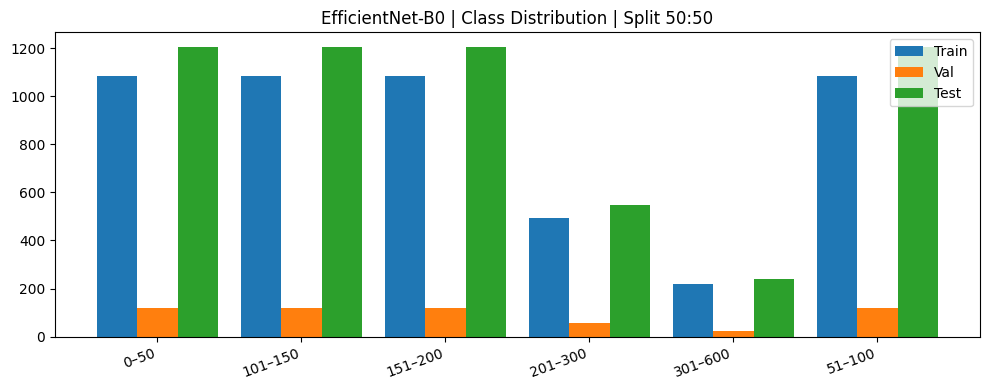

In [7]:
def count_labels(df):
    return [int((df["_label"]==i).sum()) for i in range(NUM_CLASSES)]

tr_cnt = count_labels(train_sub)
va_cnt = count_labels(val_sub)
te_cnt = count_labels(test_sub)
df_dist = pd.DataFrame({"Class":CLASS_NAMES,"Train":tr_cnt,"Val":va_cnt,"Test":te_cnt})
print(df_dist.to_string(index=False))

x = np.arange(NUM_CLASSES); w = 0.28
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(x-w, tr_cnt, w, label="Train")
ax.bar(x,   va_cnt, w, label="Val")
ax.bar(x+w, te_cnt, w, label="Test")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right")
ax.set_title(f"EfficientNet-B0 | Class Distribution | Split 50:50")
ax.legend(); plt.tight_layout(); plt.show()

## 7 · Build Model & Compute GFLOPs

In [8]:
model = timm.create_model(TIMM_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params — Total:{total_p/1e6:.2f}M | Trainable:{train_p/1e6:.2f}M")

dummy = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(DEVICE)
macs, _ = thop_profile(model, inputs=(dummy,), verbose=False)
gflops  = macs / 1e9
print(f"GFLOPs @ {IMG_SIZE}×{IMG_SIZE} : {gflops:.3f}")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Params — Total:4.02M | Trainable:4.02M
GFLOPs @ 224×224 : 0.385


## 8 · Training

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

history = {k:[] for k in ["train_loss","train_acc","val_loss","val_acc"]}
best_val_loss, patience_cnt, best_state = float("inf"), 0, None
train_wall_start = time.time()

for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    tl, tc, tt = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs); loss = criterion(out, lbls)
        loss.backward(); optimizer.step()
        tl += loss.item()*imgs.size(0)
        tc += (out.argmax(1)==lbls).sum().item()
        tt += imgs.size(0)
    tl/=tt; ta=tc/tt

    model.eval(); vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out = model(imgs); loss = criterion(out, lbls)
            vl += loss.item()*imgs.size(0)
            vc += (out.argmax(1)==lbls).sum().item()
            vt += imgs.size(0)
    vl/=vt; va=vc/vt
    scheduler.step()

    for k,v in zip(["train_loss","train_acc","val_loss","val_acc"],[tl,ta,vl,va]):
        history[k].append(v)

    if vl < best_val_loss:
        best_val_loss=vl; patience_cnt=0
        best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
    else:
        patience_cnt+=1

    if epoch%5==0 or epoch==1:
        print(f"Ep {epoch:03d}/{MAX_EPOCHS} | TrL={tl:.4f} TrA={ta:.4f} | ValL={vl:.4f} ValA={va:.4f} | Pat={patience_cnt}/{PATIENCE}")

    if patience_cnt>=PATIENCE and epoch>=50:
        print(f"Early stop at epoch {epoch}"); break

train_wall_time = time.time()-train_wall_start
epochs_ran = len(history["train_loss"])
model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
print(f"\nTrain wall-clock : {train_wall_time:.1f}s ({train_wall_time/60:.2f} min) | Best weights restored.")

Ep 001/60 | TrL=2.3449 TrA=0.3116 | ValL=2.0822 ValA=0.3619 | Pat=0/10
Ep 005/60 | TrL=0.7797 TrA=0.6981 | ValL=1.4385 ValA=0.5134 | Pat=0/10
Ep 010/60 | TrL=0.2807 TrA=0.9021 | ValL=1.4348 ValA=0.5668 | Pat=1/10
Ep 015/60 | TrL=0.1190 TrA=0.9673 | ValL=1.4544 ValA=0.5561 | Pat=6/10
Ep 020/60 | TrL=0.0687 TrA=0.9818 | ValL=1.5617 ValA=0.5775 | Pat=11/10
Ep 025/60 | TrL=0.0454 TrA=0.9887 | ValL=1.5792 ValA=0.5936 | Pat=16/10
Ep 030/60 | TrL=0.0307 TrA=0.9933 | ValL=1.6002 ValA=0.5847 | Pat=21/10
Ep 035/60 | TrL=0.0215 TrA=0.9956 | ValL=1.6906 ValA=0.5882 | Pat=26/10
Ep 040/60 | TrL=0.0189 TrA=0.9952 | ValL=1.7037 ValA=0.5954 | Pat=31/10
Ep 045/60 | TrL=0.0129 TrA=0.9976 | ValL=1.7332 ValA=0.5918 | Pat=36/10
Ep 050/60 | TrL=0.0113 TrA=0.9970 | ValL=1.7431 ValA=0.5989 | Pat=41/10
Early stop at epoch 50

Train wall-clock : 3089.9s (51.50 min) | Best weights restored.


## 9 · Learning Curves

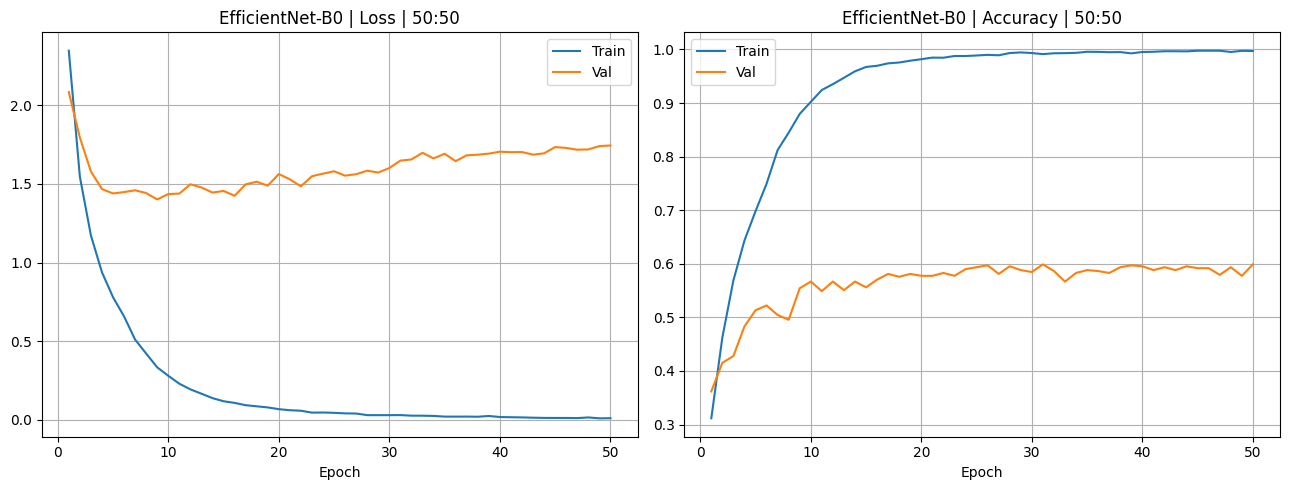

In [10]:
ep = range(1, epochs_ran+1)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(13,5))
ax1.plot(ep,history["train_loss"],label="Train"); ax1.plot(ep,history["val_loss"],label="Val")
ax1.set_title("EfficientNet-B0 | Loss | 50:50"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True)
ax2.plot(ep,history["train_acc"],label="Train"); ax2.plot(ep,history["val_acc"],label="Val")
ax2.set_title("EfficientNet-B0 | Accuracy | 50:50"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig("lc_efficientnet_50_50.png", dpi=150); plt.show()

## 10 · Test Evaluation

In [11]:
model.eval()
all_preds, all_probs, all_lbls = [], [], []
test_wall_start = time.time()
with torch.no_grad():
    for imgs, lbls in test_loader:
        logits = model(imgs.to(DEVICE))
        probs  = torch.softmax(logits,1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_lbls.extend(lbls.numpy())
test_wall_time = time.time()-test_wall_start

all_preds=np.array(all_preds); all_probs=np.array(all_probs); all_lbls=np.array(all_lbls)

acc      = accuracy_score(all_lbls,all_preds)
prec_mac = precision_score(all_lbls,all_preds,average="macro",zero_division=0)
rec_mac  = recall_score(all_lbls,all_preds,average="macro",zero_division=0)
f1_mac   = f1_score(all_lbls,all_preds,average="macro",zero_division=0)
try:    roc_auc = roc_auc_score(all_lbls,all_probs,multi_class="ovr",average="macro")
except: roc_auc = float("nan")

cm = confusion_matrix(all_lbls,all_preds)
per_class_acc = cm.diagonal()/cm.sum(axis=1)

print("="*60)
print(f"  Accuracy        : {acc:.4f}")
print(f"  Macro Precision : {prec_mac:.4f}")
print(f"  Macro Recall    : {rec_mac:.4f}")
print(f"  Macro F1        : {f1_mac:.4f}")
print(f"  Macro ROC-AUC   : {roc_auc:.4f}")
print(f"  Train Time (s)  : {train_wall_time:.1f}")
print(f"  Test  Time (s)  : {test_wall_time:.2f}")
print(f"  GFLOPs          : {gflops:.3f}")
print("="*60)
for name,pa in zip(CLASS_NAMES,per_class_acc):
    print(f"  Per-class Acc [{name}]: {pa:.4f}")
print(); print(classification_report(all_lbls,all_preds,target_names=CLASS_NAMES))

  Accuracy        : 0.5672
  Macro Precision : 0.6068
  Macro Recall    : 0.5936
  Macro F1        : 0.5990
  Macro ROC-AUC   : 0.8641
  Train Time (s)  : 3089.9
  Test  Time (s)  : 65.89
  GFLOPs          : 0.385
  Per-class Acc [0–50]: 0.5759
  Per-class Acc [101–150]: 0.5793
  Per-class Acc [151–200]: 0.6531
  Per-class Acc [201–300]: 0.7158
  Per-class Acc [301–600]: 0.6639
  Per-class Acc [51–100]: 0.3734

              precision    recall  f1-score   support

        0–50       0.53      0.58      0.55      1205
     101–150       0.52      0.58      0.55      1205
     151–200       0.71      0.65      0.68      1205
     201–300       0.73      0.72      0.72       549
     301–600       0.74      0.66      0.70       241
      51–100       0.41      0.37      0.39      1205

    accuracy                           0.57      5610
   macro avg       0.61      0.59      0.60      5610
weighted avg       0.57      0.57      0.57      5610



## 11 · Confusion Matrix & Failure Modes

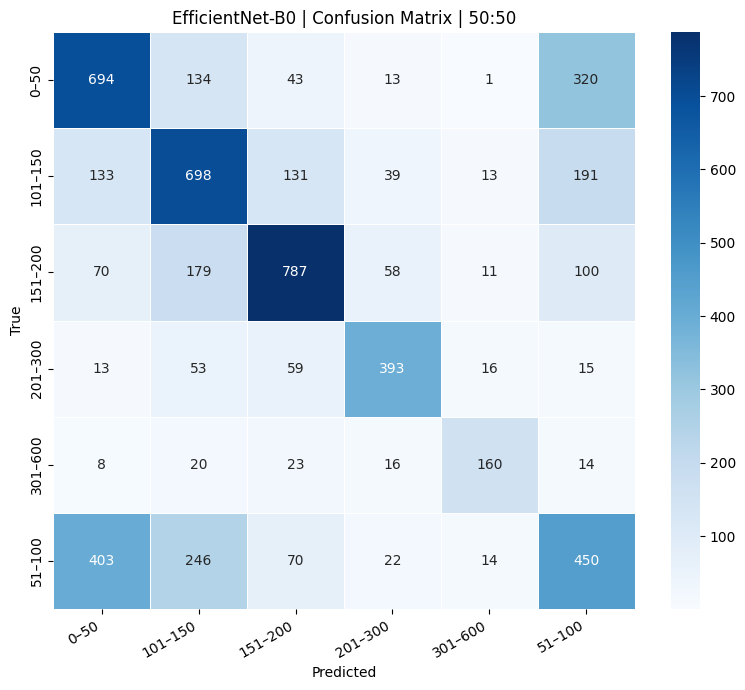

Top confused pairs:
  True=51–100 → Pred=0–50 : 403
  True=0–50 → Pred=51–100 : 320
  True=51–100 → Pred=101–150 : 246
  True=101–150 → Pred=51–100 : 191
  True=151–200 → Pred=101–150 : 179
  True=0–50 → Pred=101–150 : 134
  True=101–150 → Pred=0–50 : 133
  True=101–150 → Pred=151–200 : 131


In [12]:
fig,ax = plt.subplots(figsize=(8,7))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax,linewidths=0.5)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"EfficientNet-B0 | Confusion Matrix | 50:50")
plt.xticks(rotation=30,ha="right"); plt.tight_layout()
plt.savefig("cm_efficientnet_50_50.png",dpi=150); plt.show()

print("Top confused pairs:")
od=[(cm[i,j],CLASS_NAMES[i],CLASS_NAMES[j])
    for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i!=j and cm[i,j]>0]
for cnt,t,p in sorted(od,reverse=True)[:8]:
    print(f"  True={t} → Pred={p} : {cnt}")

## 12 · ROC Curves

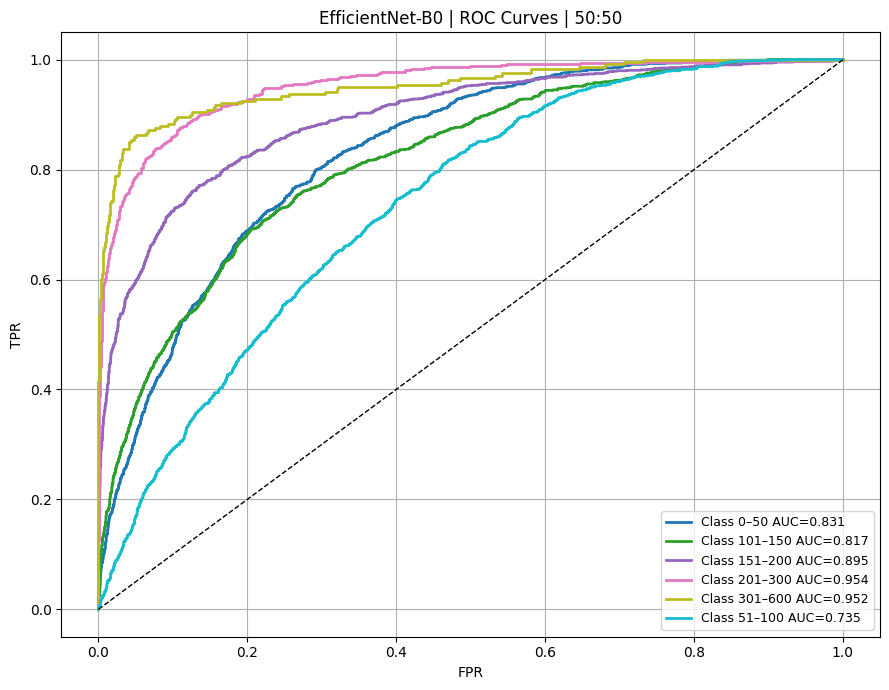

In [13]:
lbls_bin = label_binarize(all_lbls,classes=list(range(NUM_CLASSES)))
fig,ax   = plt.subplots(figsize=(9,7))
colors   = plt.cm.tab10(np.linspace(0,1,NUM_CLASSES))
for i in range(NUM_CLASSES):
    try:
        fpr,tpr,_ = roc_curve(lbls_bin[:,i],all_probs[:,i])
        auc_i = roc_auc_score(lbls_bin[:,i],all_probs[:,i])
        ax.plot(fpr,tpr,color=colors[i],lw=2,label=f"Class {CLASS_NAMES[i]} AUC={auc_i:.3f}")
    except: pass
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title(f"EfficientNet-B0 | ROC Curves | 50:50")
ax.legend(loc="lower right",fontsize=9); ax.grid(True); plt.tight_layout()
plt.savefig("roc_efficientnet_50_50.png",dpi=150); plt.show()

## 13 · Save Summary CSV

In [14]:
summary = {
    "Model":MODEL_NAME, "Split":"50:50",
    "Input Size":f"{IMG_SIZE}x{IMG_SIZE}", "GFLOPs":round(gflops,3),
    "Train Samples":len(train_sub), "Val Samples":len(val_sub),
    "Test Samples":len(test_sub),   "Epochs Run":epochs_ran,
    "Accuracy":round(acc,4),
    "Macro Precision":round(prec_mac,4),
    "Macro Recall":round(rec_mac,4),
    "Macro F1":round(f1_mac,4),
    "Macro ROC-AUC":round(float(roc_auc),4),
    "Train Time (s)":round(train_wall_time,1),
    "Test Time (s)":round(test_wall_time,2),
}
for k,v in summary.items(): print(f"  {k:22s}: {v}")
fname = f"summary_efficientnet_split50_50.csv"
pd.DataFrame([summary]).to_csv(fname,index=False)
print(f"\nSaved: {fname}")

  Model                 : EfficientNet-B0
  Split                 : 50:50
  Input Size            : 224x224
  GFLOPs                : 0.385
  Train Samples         : 5048
  Val Samples           : 561
  Test Samples          : 5610
  Epochs Run            : 50
  Accuracy              : 0.5672
  Macro Precision       : 0.6068
  Macro Recall          : 0.5936
  Macro F1              : 0.599
  Macro ROC-AUC         : 0.8641
  Train Time (s)        : 3089.9
  Test Time (s)         : 65.89

Saved: summary_efficientnet_split50_50.csv
